In [1]:
import radarsimpy

print("`RadarSimPy` used in this example is version: " + str(radarsimpy.__version__))

`RadarSimPy` used in this example is version: 12.5.0


In [2]:
import pymeshlab
print("pymeshlab imported successfully!")


pymeshlab imported successfully!


In [3]:
import pymeshlab
import numpy as np

target = {
    "model": "/home/hawk/GitDir/Blender's files/Edited files/quadcopter.stl",
    "unit": "m",
    "location": (0, 0, 0),
}

_Plot the model_


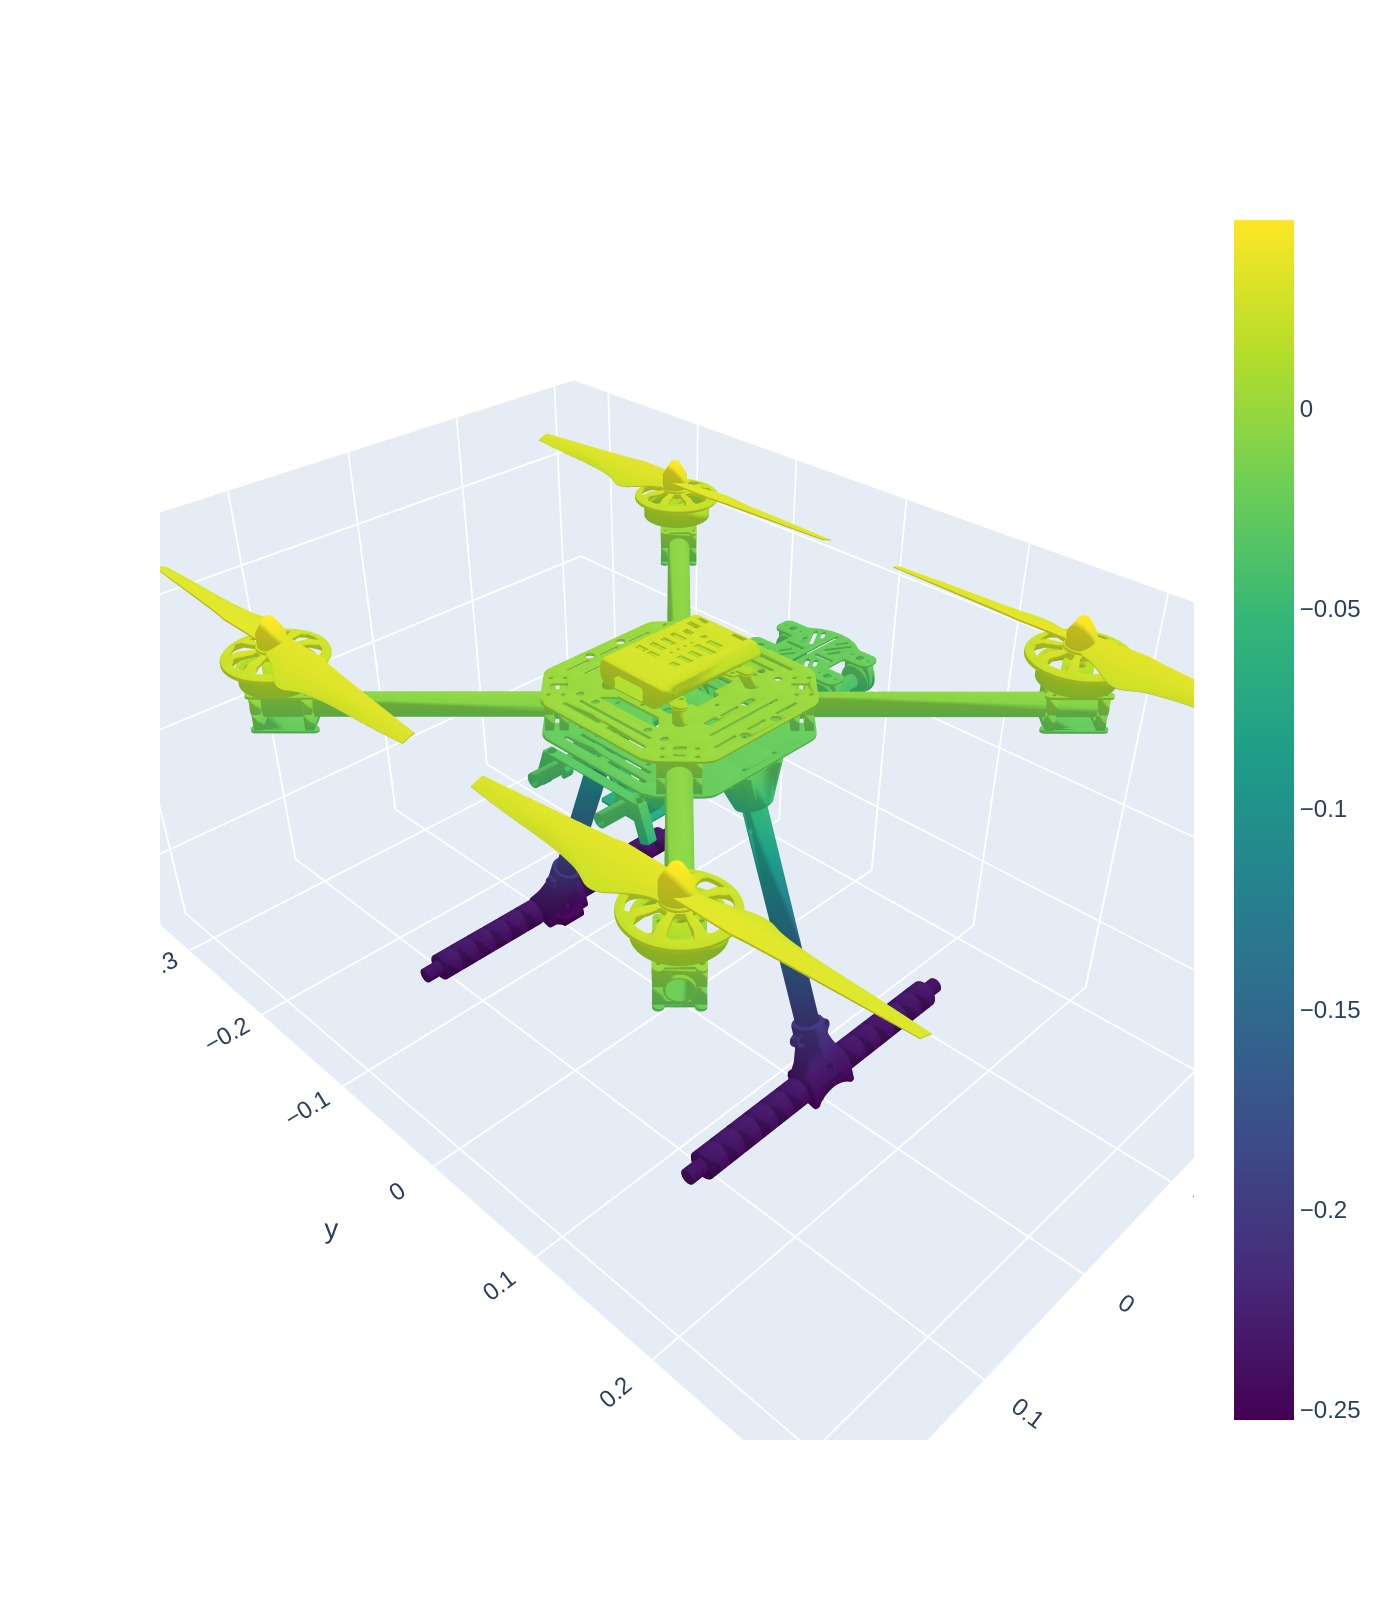

In [4]:
import plotly.graph_objs as go
from IPython.display import Image

ms = pymeshlab.MeshSet()
ms.load_new_mesh(target["model"])
t_mesh = ms.current_mesh()
v_matrix = np.array(t_mesh.vertex_matrix())
f_matrix = np.array(t_mesh.face_matrix())

fig = go.Figure()
fig.add_trace(
    go.Mesh3d(
        x=v_matrix[:, 0],
        y=v_matrix[:, 1],
        z=v_matrix[:, 2],
        i=f_matrix[:, 0],
        j=f_matrix[:, 1],
        k=f_matrix[:, 2],
        intensity=v_matrix[:, 2],
        colorscale="Viridis",
    )
)
fig["layout"]["scene"]["aspectmode"] = "data"
fig["layout"]["height"] = 800

# uncomment this to display interactive plot
# fig.show()

# display static image to reduce size on radarsimx.com
img_bytes = fig.to_image(format="jpg", scale=2)
display(Image(img_bytes))

## Simulate RCS vs Observation Angle


In [8]:
import time

from radarsimpy.rt import rcs_sbr

phi = np.arange(-180, 180, 1)
theta = 90
freq = 76e9
pol = [0, 0, 1]
density = 0.1

rcs = np.zeros_like(phi)

tic = time.time()
for phi_idx, phi_ang in enumerate(phi):
    rcs[phi_idx] = 10 * np.log10(
        rcs_sbr([target], freq, phi_ang, theta, pol, density=density)
    )
toc = time.time()

print("Exec time :" + str(toc - tic) + "s")

Exec time :125.35654067993164s


_Plot RCS vs angle_


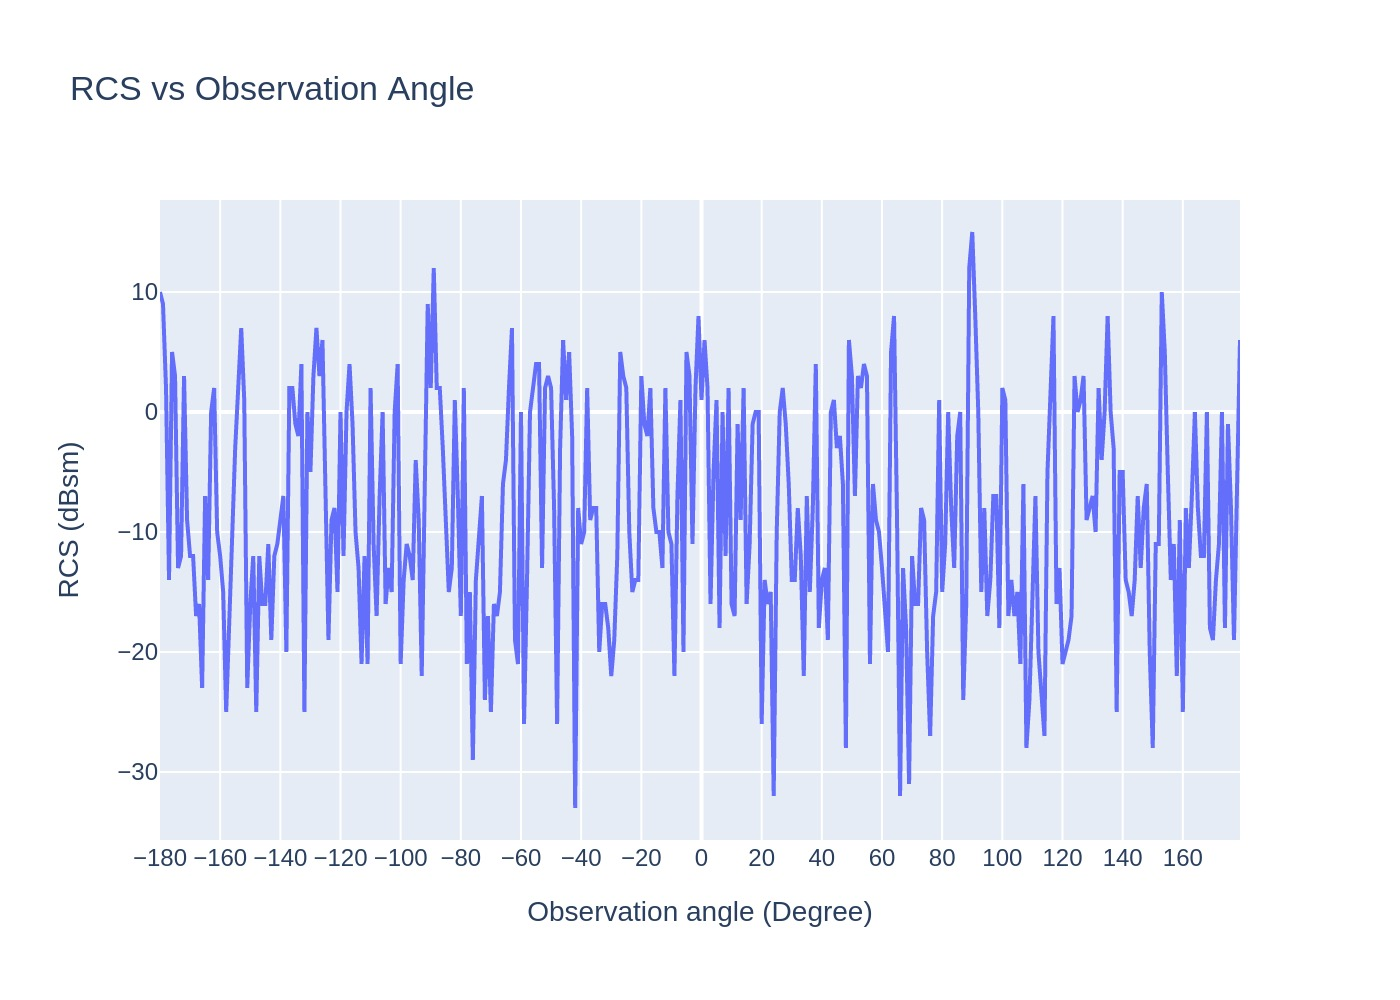

In [9]:
fig = go.Figure()

fig.add_trace(go.Scatter(x=phi, y=rcs))

fig.update_layout(
    title="RCS vs Observation Angle",
    yaxis=dict(title="RCS (dBsm)"),
    xaxis=dict(title="Observation angle (Degree)", dtick=20),
)

# uncomment this to display interactive plot
# fig.show()

# display static image to reduce size on radarsimx.com
img_bytes = fig.to_image(format="jpg", scale=2)
display(Image(img_bytes))